# **Intro: Publication-Quality Figures in Python**

So, you want to make your figures look good in $\LaTeX$? 

Follow this guide.The most important thing is to never arbitrarily scale your figures in your document editor. Instead, define the exact dimensions in Python and export them as vector graphics. This ensures your font sizes and line weights remain consistent with the rest of your paper.

**Written By:** Derek Benham \
**Last Updated:** February 2026

## 1. Figure Size

Randomly scaling your matplotlib figures to look good in your text is not the right way to do things!

When you create a figure in matplotlib, you can provide a size argumunent, but first, we need to know what that size is. In Latex, add these commands anywhere in the body text of your document


`The column width is: \the\columnwidth`\
`The total text width is: \the\textwidth`


Now when you recompile your paper, you should see how wide your figure is, in points (pt). Don't forget to remove them after you get the value!


For the IEEE RAS template you should get the following values:
<ul>
    <li>The column width is: 245.71811 pt</li>
    <li>The total text width is: 505.89 pt</li>
</ul>

You can convert these values to inches as 1 inch = 72.27 points in Latex

In [31]:
def pt_to_inches(pt):
    return pt / 72.27 # 1 inch = 72.27 points in Latex

col_width_pt = 245.71811
COL_WIDTH_IN = pt_to_inches(col_width_pt)

page_width_pt = 505.89
PAGE_WIDTH_IN = pt_to_inches(page_width_pt)

Now that you have the width, you can scale the height of the figure to look best depending on what you're plotting.

## 2. Imports and Preemble

Matplotlib is great, but I would advice adding seaborn as well. It's a matplotlib wrapper that makes things look a little more professional.

`pip install seaborn `


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

You'll also want to add the following information before your figure. 

It's best practice to save figures as a PDF to get the best resolution in Latex.

The SNS color palette helps maintain accessibility for your figures

You want your font to be consistent. This is from IJRR: Fonts: The lettering used in the artwork should not vary too much in size and type (usually Sans Serif font is a default). 

In [33]:
FIGURE_WIDTH = COL_WIDTH_IN # Standard for 1-column figures (use PAGE_WIDTH_IN for 2-column)

ASPECT_RATIO = 0.75 # Height = WIDTH * ASPECT_RATIO
FIG_SIZE = (FIGURE_WIDTH, FIGURE_WIDTH * ASPECT_RATIO)

# Font Sizes (Standard for 1-column figures)
FS_TITLE = 10
FS_LABEL = 10
FS_TICK = 10
FS_LEGEND = 10

# --- 2. GLOBAL SETTINGS ---
plt.rcParams.update({
    "pdf.fonttype": 42,           # Editable text for Illustrator/Journals
    "ps.fonttype": 42,
    "font.family": "sans-serif",  # Most journals prefer Arial or Helvetica
    "font.sans-serif": ["Arial"],
    "mathtext.fontset": "stix",  # Use STIX fonts for math (similar to Times)
    "axes.titlesize": FS_TITLE,
    "axes.labelsize": FS_LABEL,
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND,
    "figure.figsize": FIG_SIZE,
    "savefig.dpi": 300            # High resolution for print
})



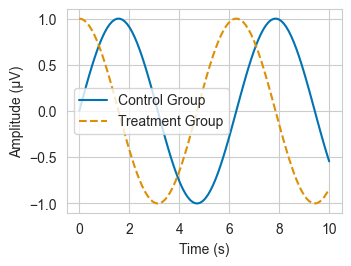

In [34]:
import numpy as np

# Use Seaborn's colorblind palette and whitegrid style
sns.set_style("whitegrid")
sns.set_palette("colorblind")

# --- 3. PLOT CREATION ---
def create_example_plot():
    # Generating dummy data
    x = np.linspace(0, 10, 100)
    y1 = np.sin(x)
    y2 = np.cos(x)

    fig, ax = plt.subplots(layout="constrained")
    
    ax.plot(x, y1, label="Control Group", lw=1.5)
    ax.plot(x, y2, label="Treatment Group", lw=1.5, linestyle="--")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    ax.legend(frameon=True)

    # Save with tight boundaries to prevent clipping

    # You want to make pad_inches small to keep your figure tight like unto a dish. But not too tight that it clips text!
    plt.savefig("example_figs/example_plot.pdf", format="pdf", bbox_inches="tight", pad_inches=0.01)
    plt.show()

create_example_plot()

# **Other Cool Features:**

Please feel free to add to this section with cool plotting features you've found.

## Violin Plots

Violin plots estimate the probability distirubtion of your data in a way slightly more visual than a box and whisker plot.

https://seaborn.pydata.org/generated/seaborn.violinplot.html

They are great if you want to show timing metrics of function calls for example, however they work best with Pandas dataframes.

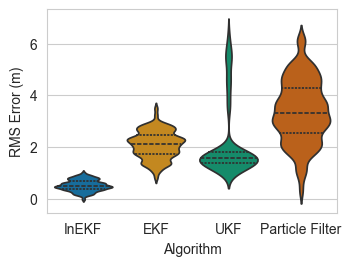

In [35]:
import pandas as pd

def plot_algo_performance():
    """
    Updated comparison for Seaborn v0.13.0+
    Fixes the 'palette without hue' deprecation warning.
    """
    # (Data generation remains the same)
    data = {
        'Algorithm': (['InEKF'] * 100) + (['EKF'] * 100) + (['UKF'] * 100) + (['Particle Filter'] * 100),
        'Error (cm)': np.concatenate([
            np.random.normal(0.5, 0.25, 100),
            np.random.normal(2, 0.5, 100),
            np.concatenate([np.random.normal(1.5, 0.2, 80), np.random.normal(5, 1.0, 20)]),
            np.random.normal(3.5, 1.2, 100),
        ])
    }
    df = pd.DataFrame(data)

    fig, ax = plt.subplots(layout="constrained")

    sns.violinplot(
        data=df, 
        x='Algorithm', 
        y='Error (cm)', 
        hue='Algorithm',  # Explicitly map color to the category
        palette="colorblind", 
        legend=False,      # Removes the redundant legend
        inner="quartile", 
        bw_adjust=0.5, 
        ax=ax
    )
    ax.set_ylabel(r"RMS Error (m)")
    plt.savefig("example_figs/violin_plot.pdf", bbox_inches="tight", pad_inches=0.01)
    plt.show()


plot_algo_performance()